
 <div style="background-color:orange; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">  Bangla License Plate Detection (YOLOv9) </h1>
</div>

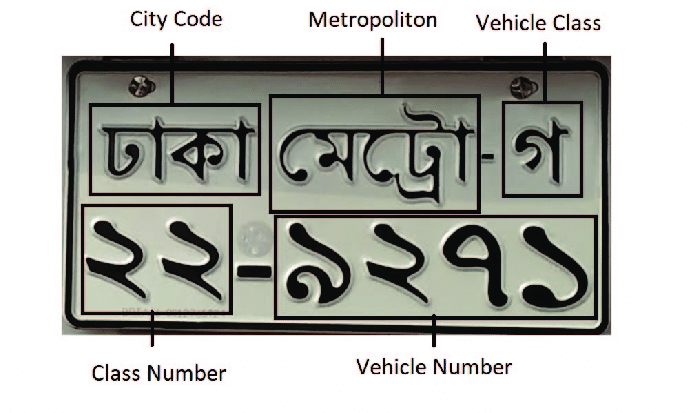

 <div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">Import Libraries & Model </h1>
</div>

In [1]:
import numpy as np 
import pandas as pd 

In [2]:
import os

base = "/kaggle/input/bangla-lpdb-a/Bangla LPDB - A/Bangladeshi_Vehicle_Image_with_visible_license_plate"

image_count = 0
text_count = 0
image_samples = []
text_samples = []

for filename in os.listdir(base):
    name = filename.lower()
    if name.endswith((".jpg", ".jpeg", ".png")):
        image_count += 1
        if len(image_samples) < 5:
            image_samples.append(filename)
    elif name.endswith(".txt"):
        text_count += 1
        if len(text_samples) < 5:
            text_samples.append(filename)

print(f"Found {image_count} image files.")
print(f"Found {text_count} text files.\n")

print("Sample image files:")
for img in image_samples:
    print(img)

print("\nSample text files:")
for txt in text_samples:
    print(txt)


Found 1929 image files.
Found 1930 text files.

Sample image files:
Vehicle75.jpg
Vehicle1071.jpg
Vehicle1917.jpeg
Vehicle661.jpg
Vehicle749.jpg

Sample text files:
Vehicle924.txt
Vehicle254.txt
Vehicle1003.txt
Vehicle1475.txt
Vehicle898.txt


In [3]:
!nvidia-smi

Mon Jun  1 07:32:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


In [5]:
!git clone https://github.com/SkalskiP/yolov9.git
%cd yolov9
!pip install -r requirements.txt -q

Cloning into 'yolov9'...
remote: Enumerating objects: 325, done.
remote: Total 325 (delta 0), reused 0 (delta 0), pack-reused 325 (from 1)
Receiving objects: 100% (325/325), 2.25 MiB | 12.50 MiB/s, done.
Resolving deltas: 100% (162/162), done.
/kaggle/working/yolov9
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 95.6 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]

In [6]:
!pip install -q roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 5.6 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 38.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 106.9 MB/s eta 0:00:0000:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.


In [7]:
# Libraries
!pip install ultralytics kaggle opencv-python pillow matplotlib torch torchvision torchaudio --upgrade

# GitHub model
!git clone https://github.com/ultralytics/ultralytics.git


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.5/128.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 94.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 102.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 3.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 8.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 9.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 31.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [8]:
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-e.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-c.pt
!wget -P {HOME}/weights -q https://github.com/WongKinYiu/yolov9/releases/download/v0.1/gelan-e.pt

In [9]:
!ls -la {HOME}/weights

total 402440
drwxr-xr-x 2 root root      4096 Jun  1 07:36 .
drwxr-xr-x 5 root root      4096 Jun  1 07:36 ..
-rw-r--r-- 1 root root  51508261 Feb 18  2024 gelan-c.pt
-rw-r--r-- 1 root root 117203713 Feb 18  2024 gelan-e.pt
-rw-r--r-- 1 root root 103153312 Feb 18  2024 yolov9-c.pt
-rw-r--r-- 1 root root 140217688 Feb 18  2024 yolov9-e.pt


In [10]:
%cd {HOME}/yolov9

/kaggle/working/yolov9


 <div style="background-color:yellow; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Folder Structure Setup (for YOLO V9 dataset )</h1>
</div>

In [11]:
!mkdir -p /kaggle/working/LPDB_A/images/train
!mkdir -p /kaggle/working/LPDB_A/images/val
!mkdir -p /kaggle/working/LPDB_A/images/test
!mkdir -p /kaggle/working/LPDB_A/labels/train
!mkdir -p /kaggle/working/LPDB_A/labels/val
!mkdir -p /kaggle/working/LPDB_A/labels/test


 <div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Dataset File Inspection Script (for Bangla LPDB-A)</h1>
</div>

In [12]:
import os

root = "/kaggle/input/bangla-lpdb-a" 

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".jfif")
text_exts = (".txt",)

for dirpath, dirnames, filenames in os.walk(root):
   
    image_files = [f for f in filenames if f.lower().endswith(image_exts)]
    text_files = [f for f in filenames if f.lower().endswith(text_exts)]
    
    if image_files or text_files:
        print(f"\n Folder: {dirpath}")
        if image_files:
            print(f"   Images ({len(image_files)}): {image_files[:5]}")
        if text_files:
            print(f"   Labels ({len(text_files)}): {text_files[:5]}")


 Folder: /kaggle/input/bangla-lpdb-a/Bangla LPDB - A/Bangladeshi_Vehicle_Image_with_visible_license_plate
   Images (1929): ['Vehicle75.jpg', 'Vehicle1071.jpg', 'Vehicle1917.jpeg', 'Vehicle661.jpg', 'Vehicle749.jpg']
   Labels (1930): ['Vehicle924.txt', 'Vehicle254.txt', 'Vehicle1003.txt', 'Vehicle1475.txt', 'Vehicle898.txt']

 Folder: /kaggle/input/bangla-lpdb-a/Bangla LPDB - A/Bangla_License_Plate
   Images (2668): ['1269.jpg', '623.jpg', '2193.jpg', '2008.jpg', '2081.jpg']
   Labels (2669): ['1893.txt', '1711.txt', '1773.txt', '559.txt', '1812.txt']


 <div style="background-color:lime; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Dataset Merge Script (Combine Two Folders) </h1>
</div>


In [13]:
import shutil
from pathlib import Path


src1 = Path("/kaggle/input/bangla-lpdb-a/Bangla LPDB - A/Bangladeshi_Vehicle_Image_with_visible_license_plate")
src2 = Path("/kaggle/input/bangla-lpdb-a/Bangla LPDB - A/Bangla_License_Plate")


merged = Path("/kaggle/working/LPDB_Merged_Full")
merged.mkdir(exist_ok=True)


for src in [src1, src2]:
    prefix = src.name.replace(" ", "_")  
    for ext in ["*.jpg", "*.JPG", "*.jpeg", "*.JPEG", "*.png", "*.bmp", "*.jfif"]:
        for img in src.glob(ext):
            new_img = merged / f"{prefix}_{img.name}"
            shutil.copy(img, new_img)
            lbl = src / (img.stem + ".txt")
            if lbl.exists():
                new_lbl = merged / f"{prefix}_{lbl.name}"
                shutil.copy(lbl, new_lbl)

print(" Total merged images:", len(list(merged.glob('*.jpg'))) + len(list(merged.glob('*.jpeg'))) + len(list(merged.glob('*.png'))))
print(" Total files (images + labels):", len(list(merged.glob('*.*'))))


 Total merged images: 4592
 Total files (images + labels): 9194



 <div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">YOLOv9 Configuration File Creation (data.yaml) </h1>
</div>


In [14]:
import yaml

data_yaml = {
    'path': '/kaggle/working/LPDB_split',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 1,
    'names': ['license_plate']
}

with open('/kaggle/working/data.yaml', 'w') as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("data.yaml created successfully!\n")
print(open('/kaggle/working/data.yaml').read())


data.yaml created successfully!

path: /kaggle/working/LPDB_split
train: images/train
val: images/val
test: images/test
nc: 1
names:
- license_plate




 <div style="background-color:yellow; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Dataset Split Script (Train / Validation / Test Creation) </h1>
</div>


In [15]:

import os, random, shutil
from pathlib import Path

merged = Path("/kaggle/working/LPDB_Merged_Full")

dst = Path("/kaggle/working/LPDB_split")
for s in ["train","val","test"]:
    (dst/"images"/s).mkdir(parents=True, exist_ok=True)
    (dst/"labels"/s).mkdir(parents=True, exist_ok=True)

images = []
for ext in ["*.jpg","*.jpeg","*.png","*.bmp","*.jfif"]:  # fixed: removed *.jpeng
    images += list(merged.glob(ext))

random.shuffle(images)

n = len(images)
n_train, n_val = int(n*0.7), int(n*0.2)
splits = {
    "train": images[:n_train],
    "val": images[n_train:n_train+n_val],
    "test": images[n_train+n_val:]
}

for split, files in splits.items():
    for img in files:
        lbl = merged / (img.stem + ".txt")
        if lbl.exists():  # copy only paired image-label
            shutil.copy(img, dst/"images"/split/img.name)
            shutil.copy(lbl, dst/"labels"/split/lbl.name)

for s in splits:
    print(s, len(list((dst/"images"/s).glob("*"))), "images")


train 3214 images
val 918 images
test 460 images


 <div style="background-color:lime; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Folder Check </h1>
</div>


In [16]:
!ls /kaggle/working/LPDB_split/images
!ls /kaggle/working/LPDB_split/labels


test  train  val
test  train  val


In [17]:
# === Relabel all YOLO txts to class 0 (single-class license_plate) ===
import os, glob, shutil

base = "/kaggle/working/LPDB_split/labels"
bk = "/kaggle/working/LPDB_labels_backup"
# backup
if os.path.exists(bk):
    shutil.rmtree(bk)
shutil.copytree(base, bk)

n_files = 0
kept = dropped = 0
for p in glob.glob(base + "/**/*.txt", recursive=True):
    n_files += 1
    out = []
    with open(p, "r") as f:
        for ln in f:
            parts = ln.strip().split()
            if len(parts) >= 5:
                try:
                    cx, cy, w, h = map(float, parts[1:5])
                except:
                    continue
                # keep only valid normalized boxes and force class=0
                if 0 <= cx <= 1 and 0 <= cy <= 1 and 0 < w <= 1 and 0 < h <= 1:
                    out.append(f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
                    kept += 1
                else:
                    dropped += 1
    with open(p, "w") as f:
        f.write("\n".join(out))
print(f"Files touched: {n_files}, boxes kept: {kept}, dropped: {dropped}")


Files touched: 4592, boxes kept: 24174, dropped: 0



 <div style="background-color:white; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;">YOLOv9 Model Training </h1>
</div>

In [18]:
!yolo train model=yolov9c.yaml data=/kaggle/working/data.yaml epochs=50 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.58 🚀 Python-3.12.13 torch-2.12.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz

In [24]:
!ls /kaggle/working/yolov9/runs/detect/train

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch8040.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch8041.jpg  weights
labels.jpg			 train_batch8042.jpg



<div style="background-color:orange; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Training Results Summary (results.png)</h1>
</div>





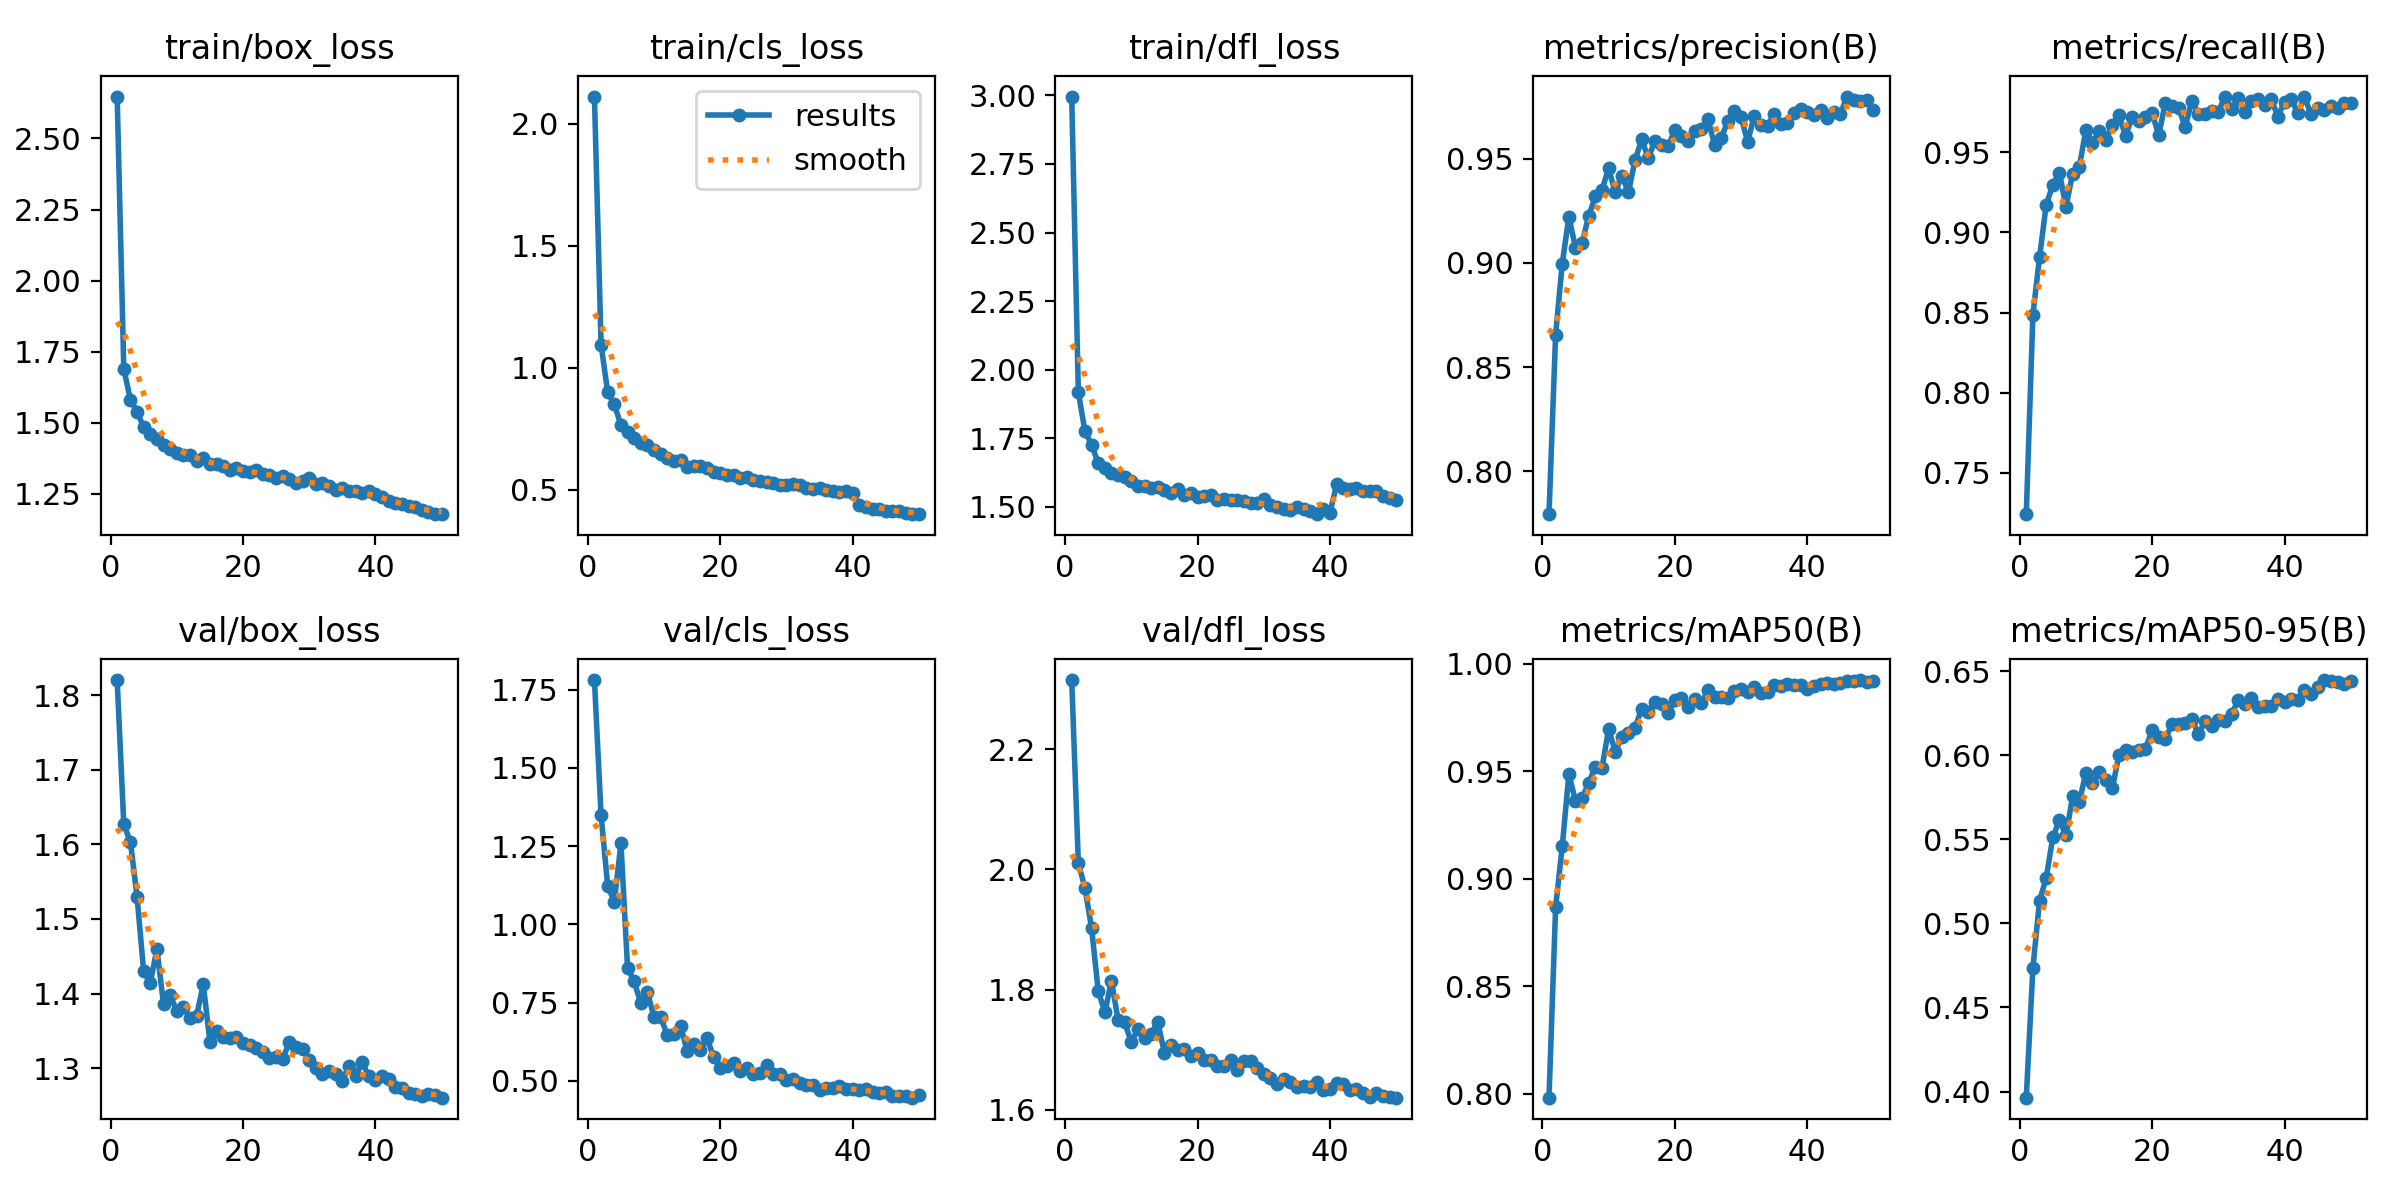

In [26]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/results.png"))

<div style="background-color:#b9fbc0; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Precision Curve (BoxP_curve.png)</h1>
</div>

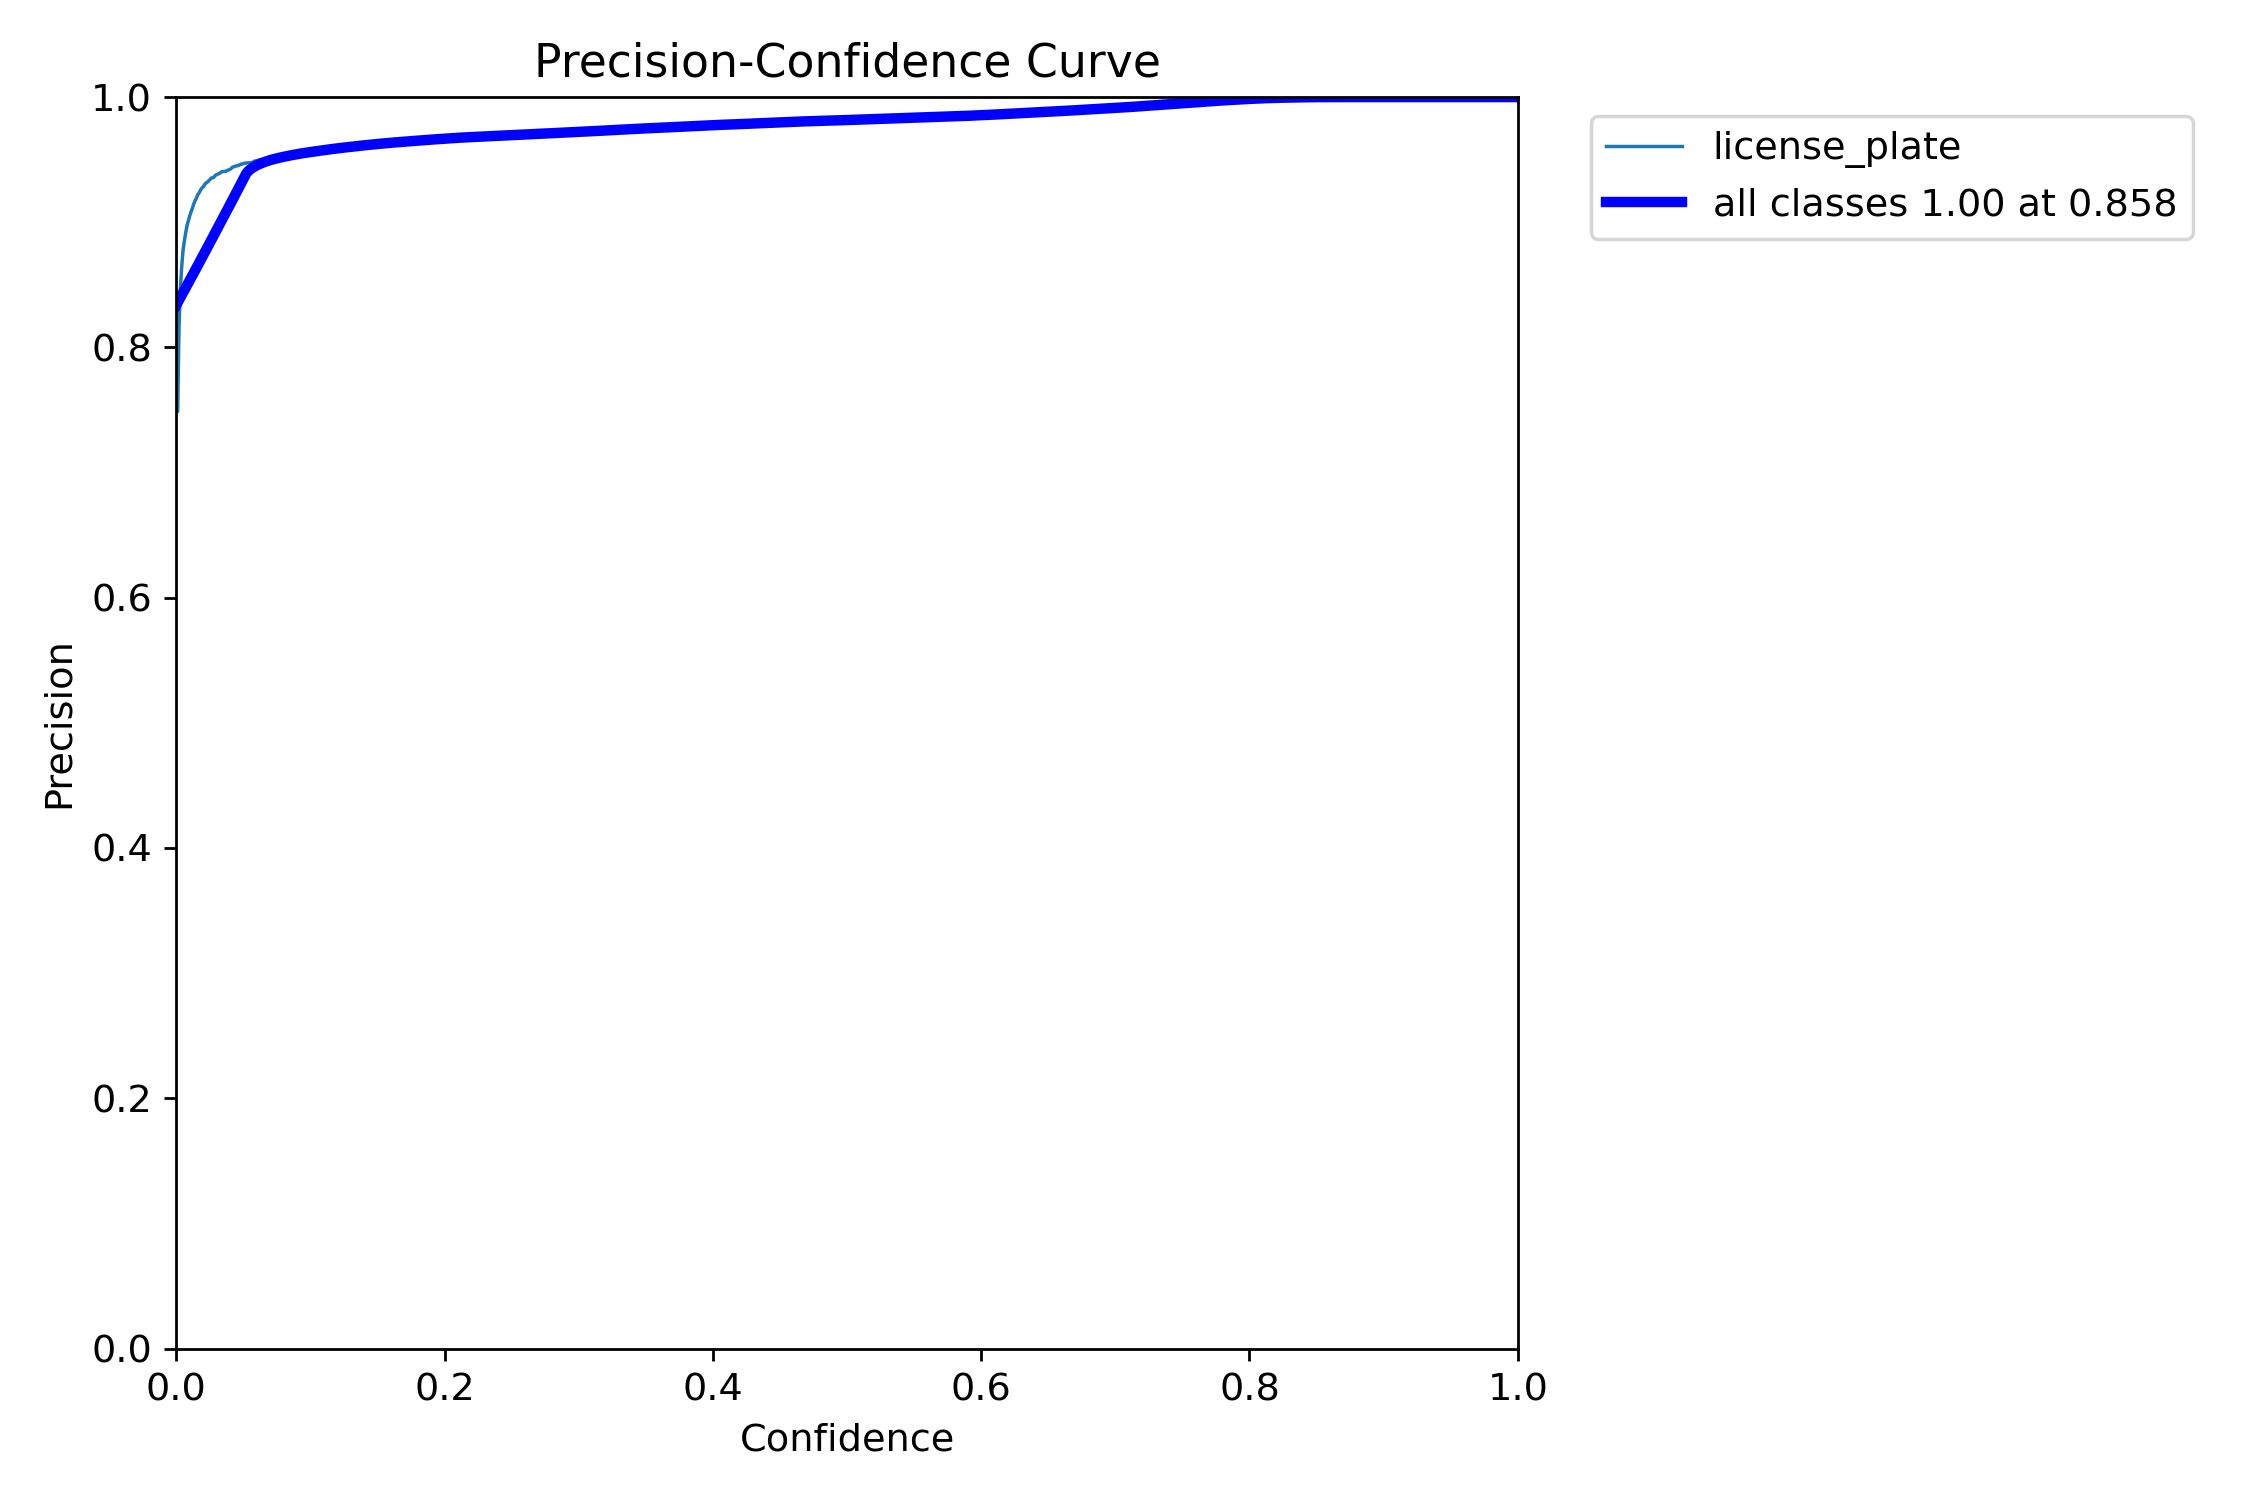

In [28]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/BoxP_curve.png"))

<div style="background-color:#fff1a8; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Recall Curve (BoxR_curve.png)</h1>
</div>

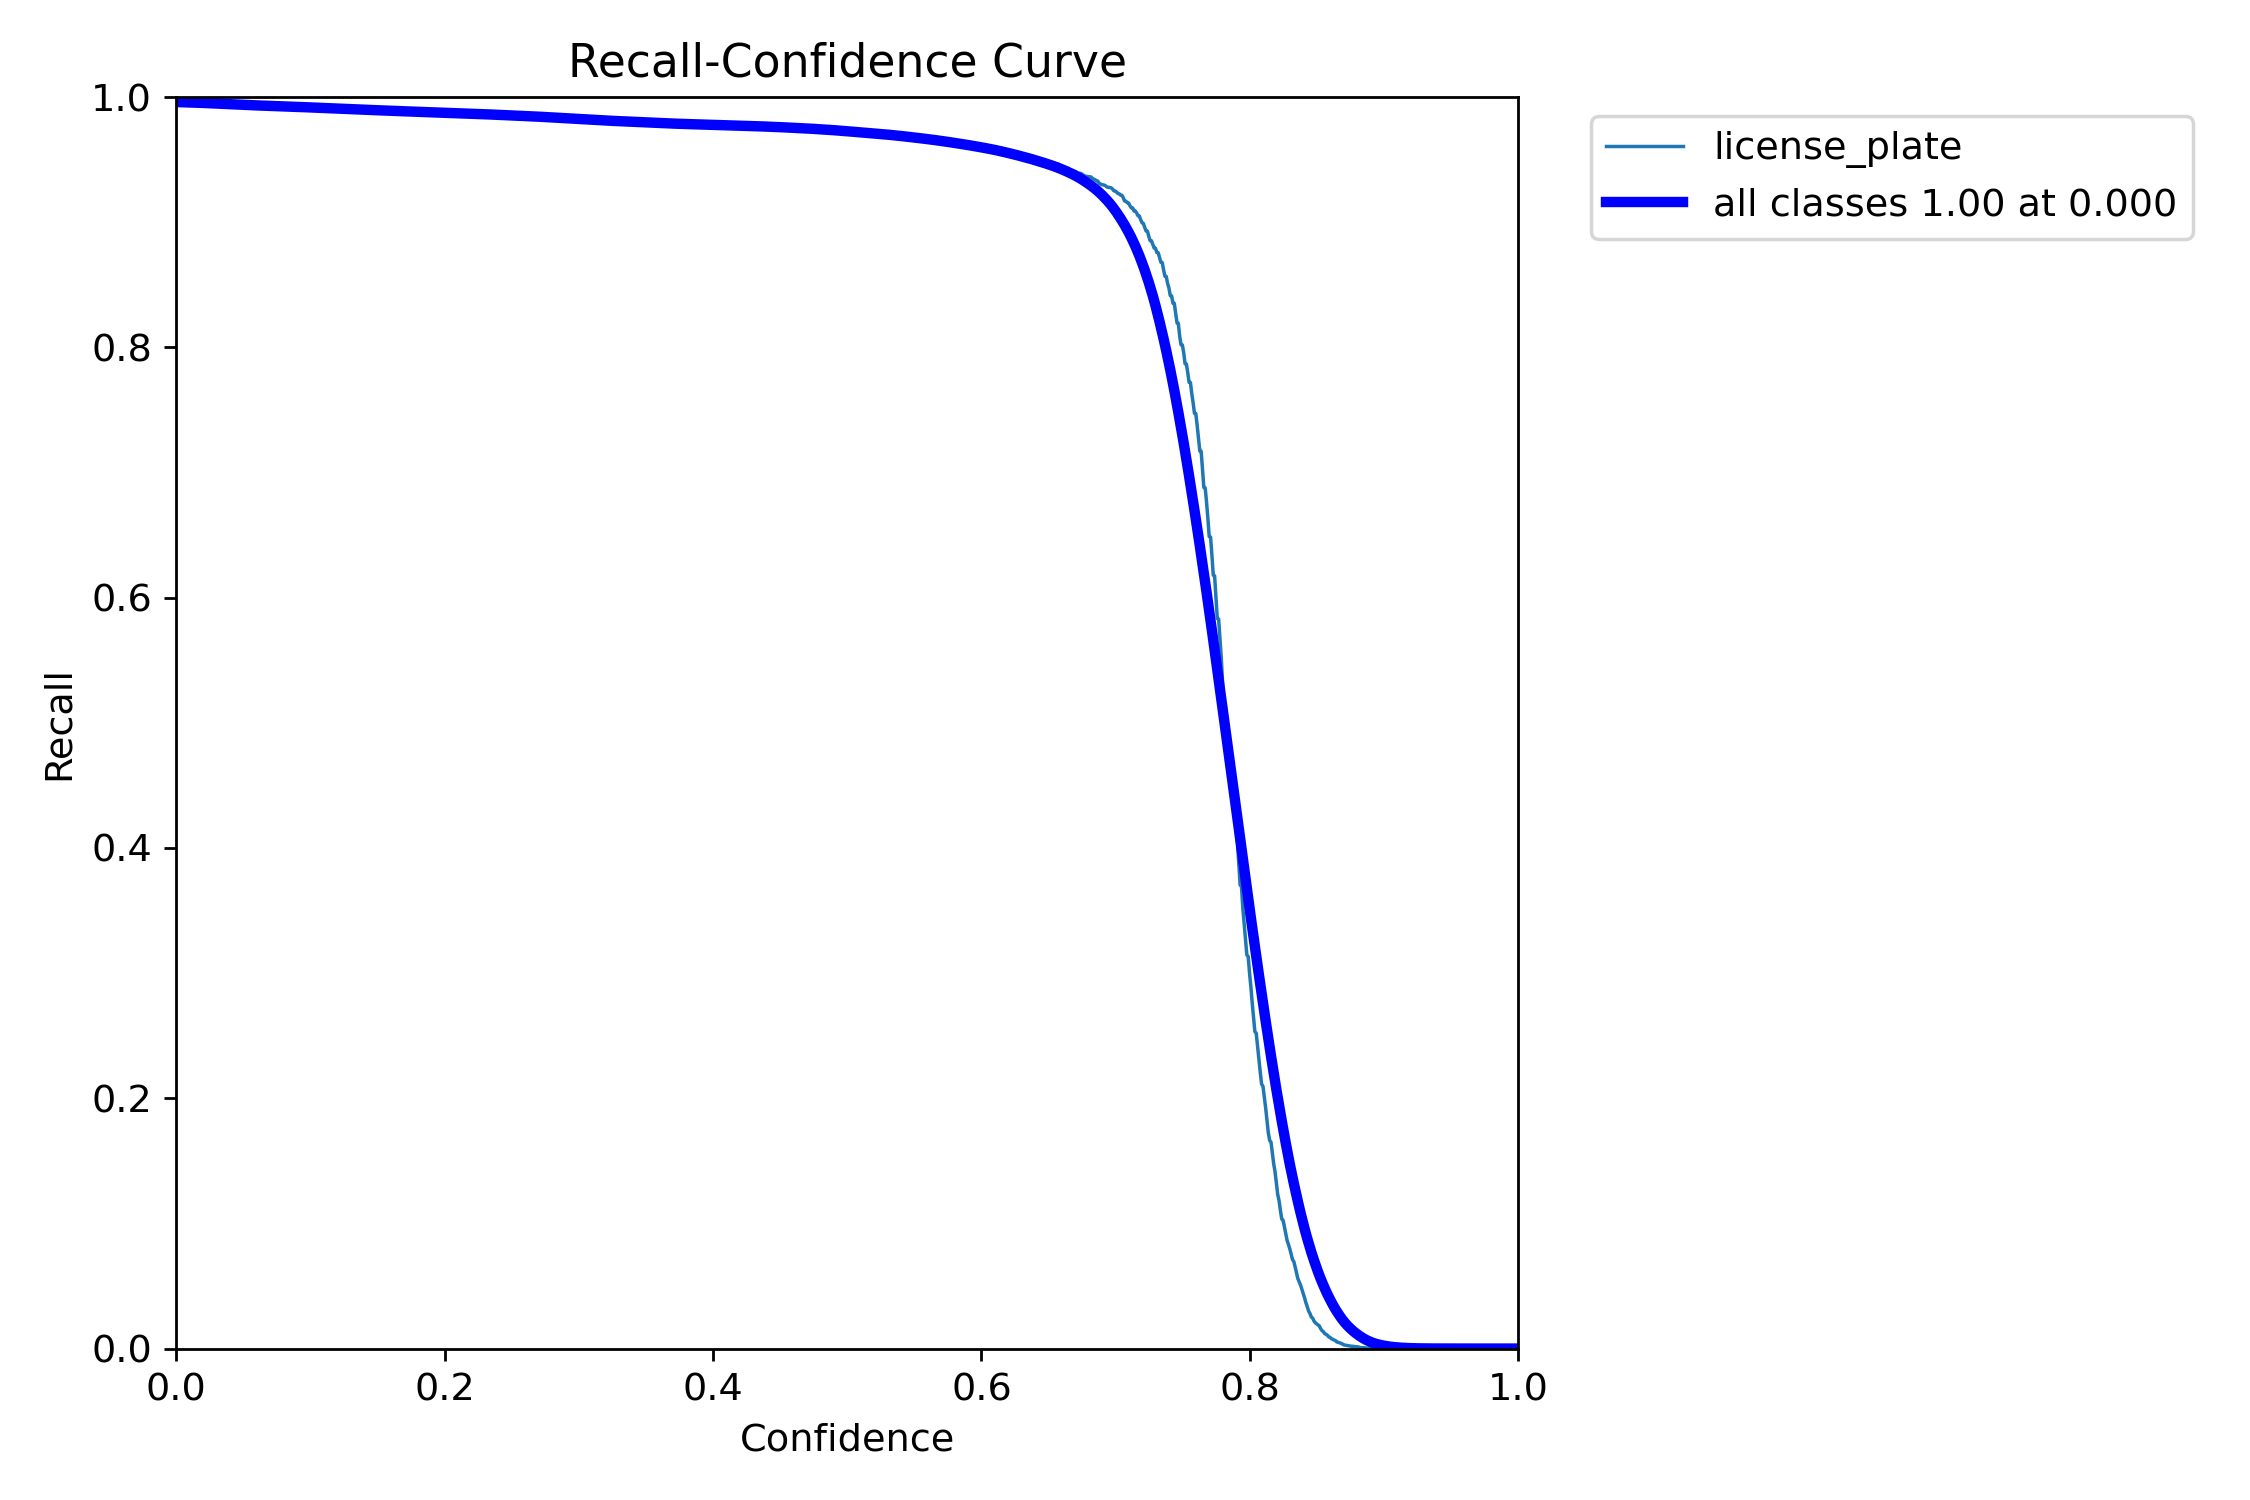

In [29]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/BoxR_curve.png"))

<div style="background-color:#a2d2ff; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Precision-Recall (PR) Curve (BoxPR_curve.png)</h1>
</div>

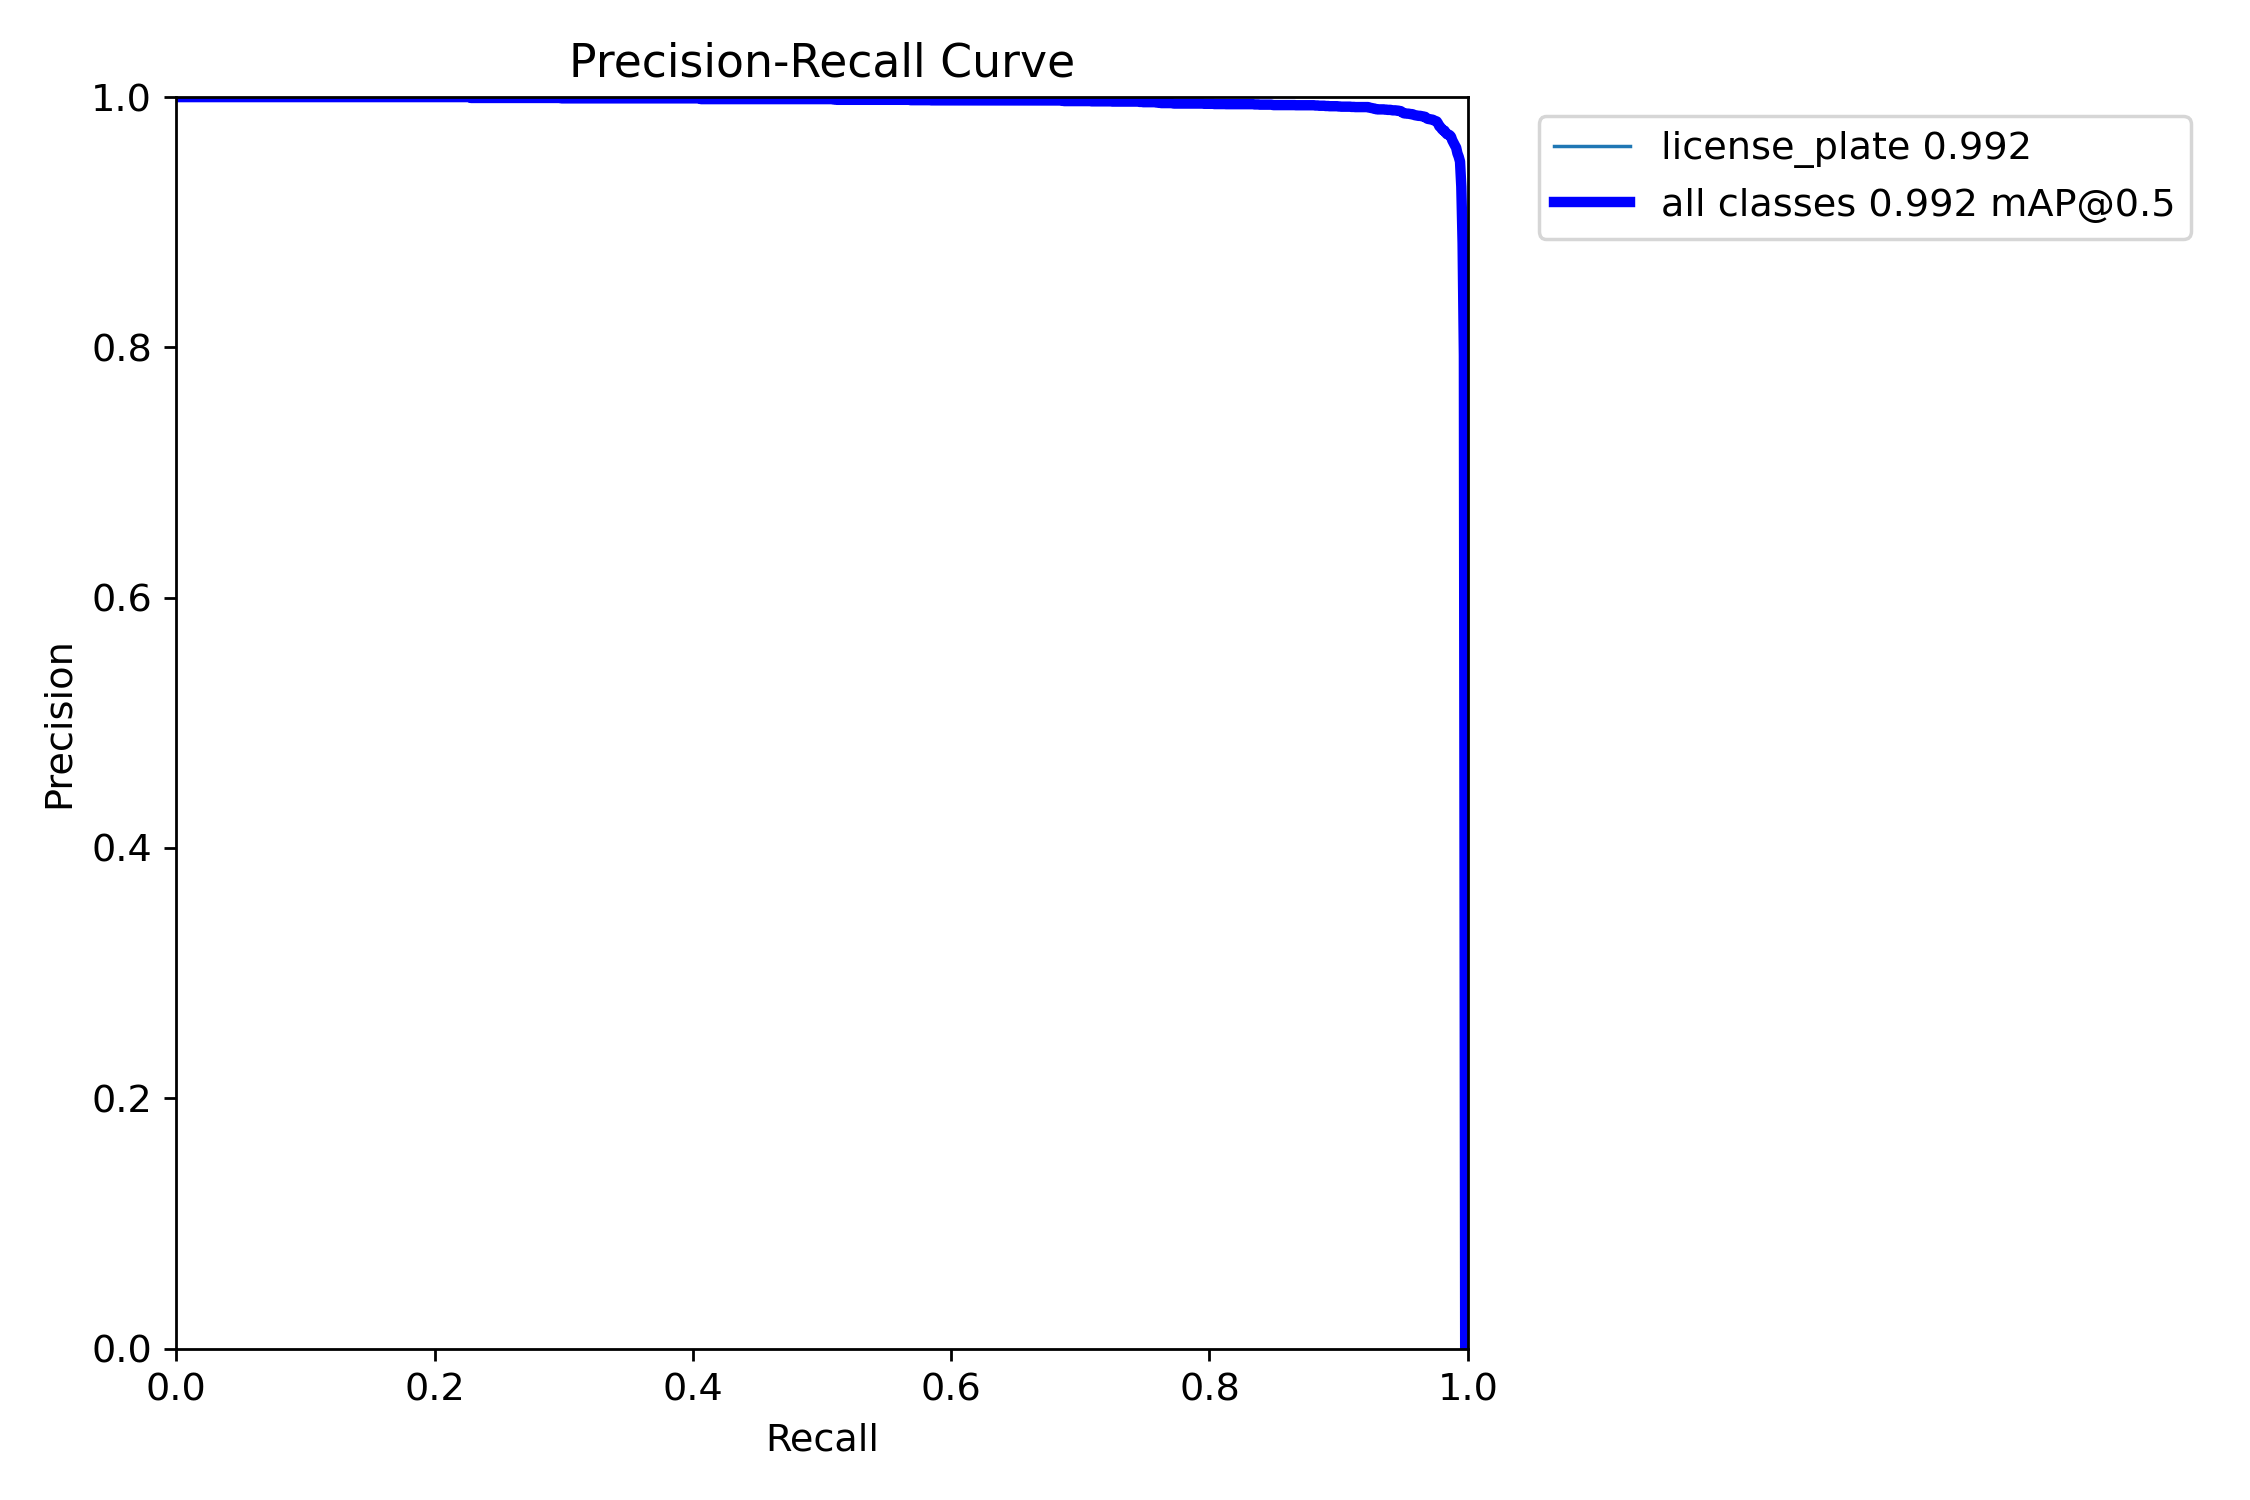

In [30]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/BoxPR_curve.png"))

<div style="background-color:#ffadad; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> F1-Score Curve (BoxF1_curve.png)</h1>
</div>

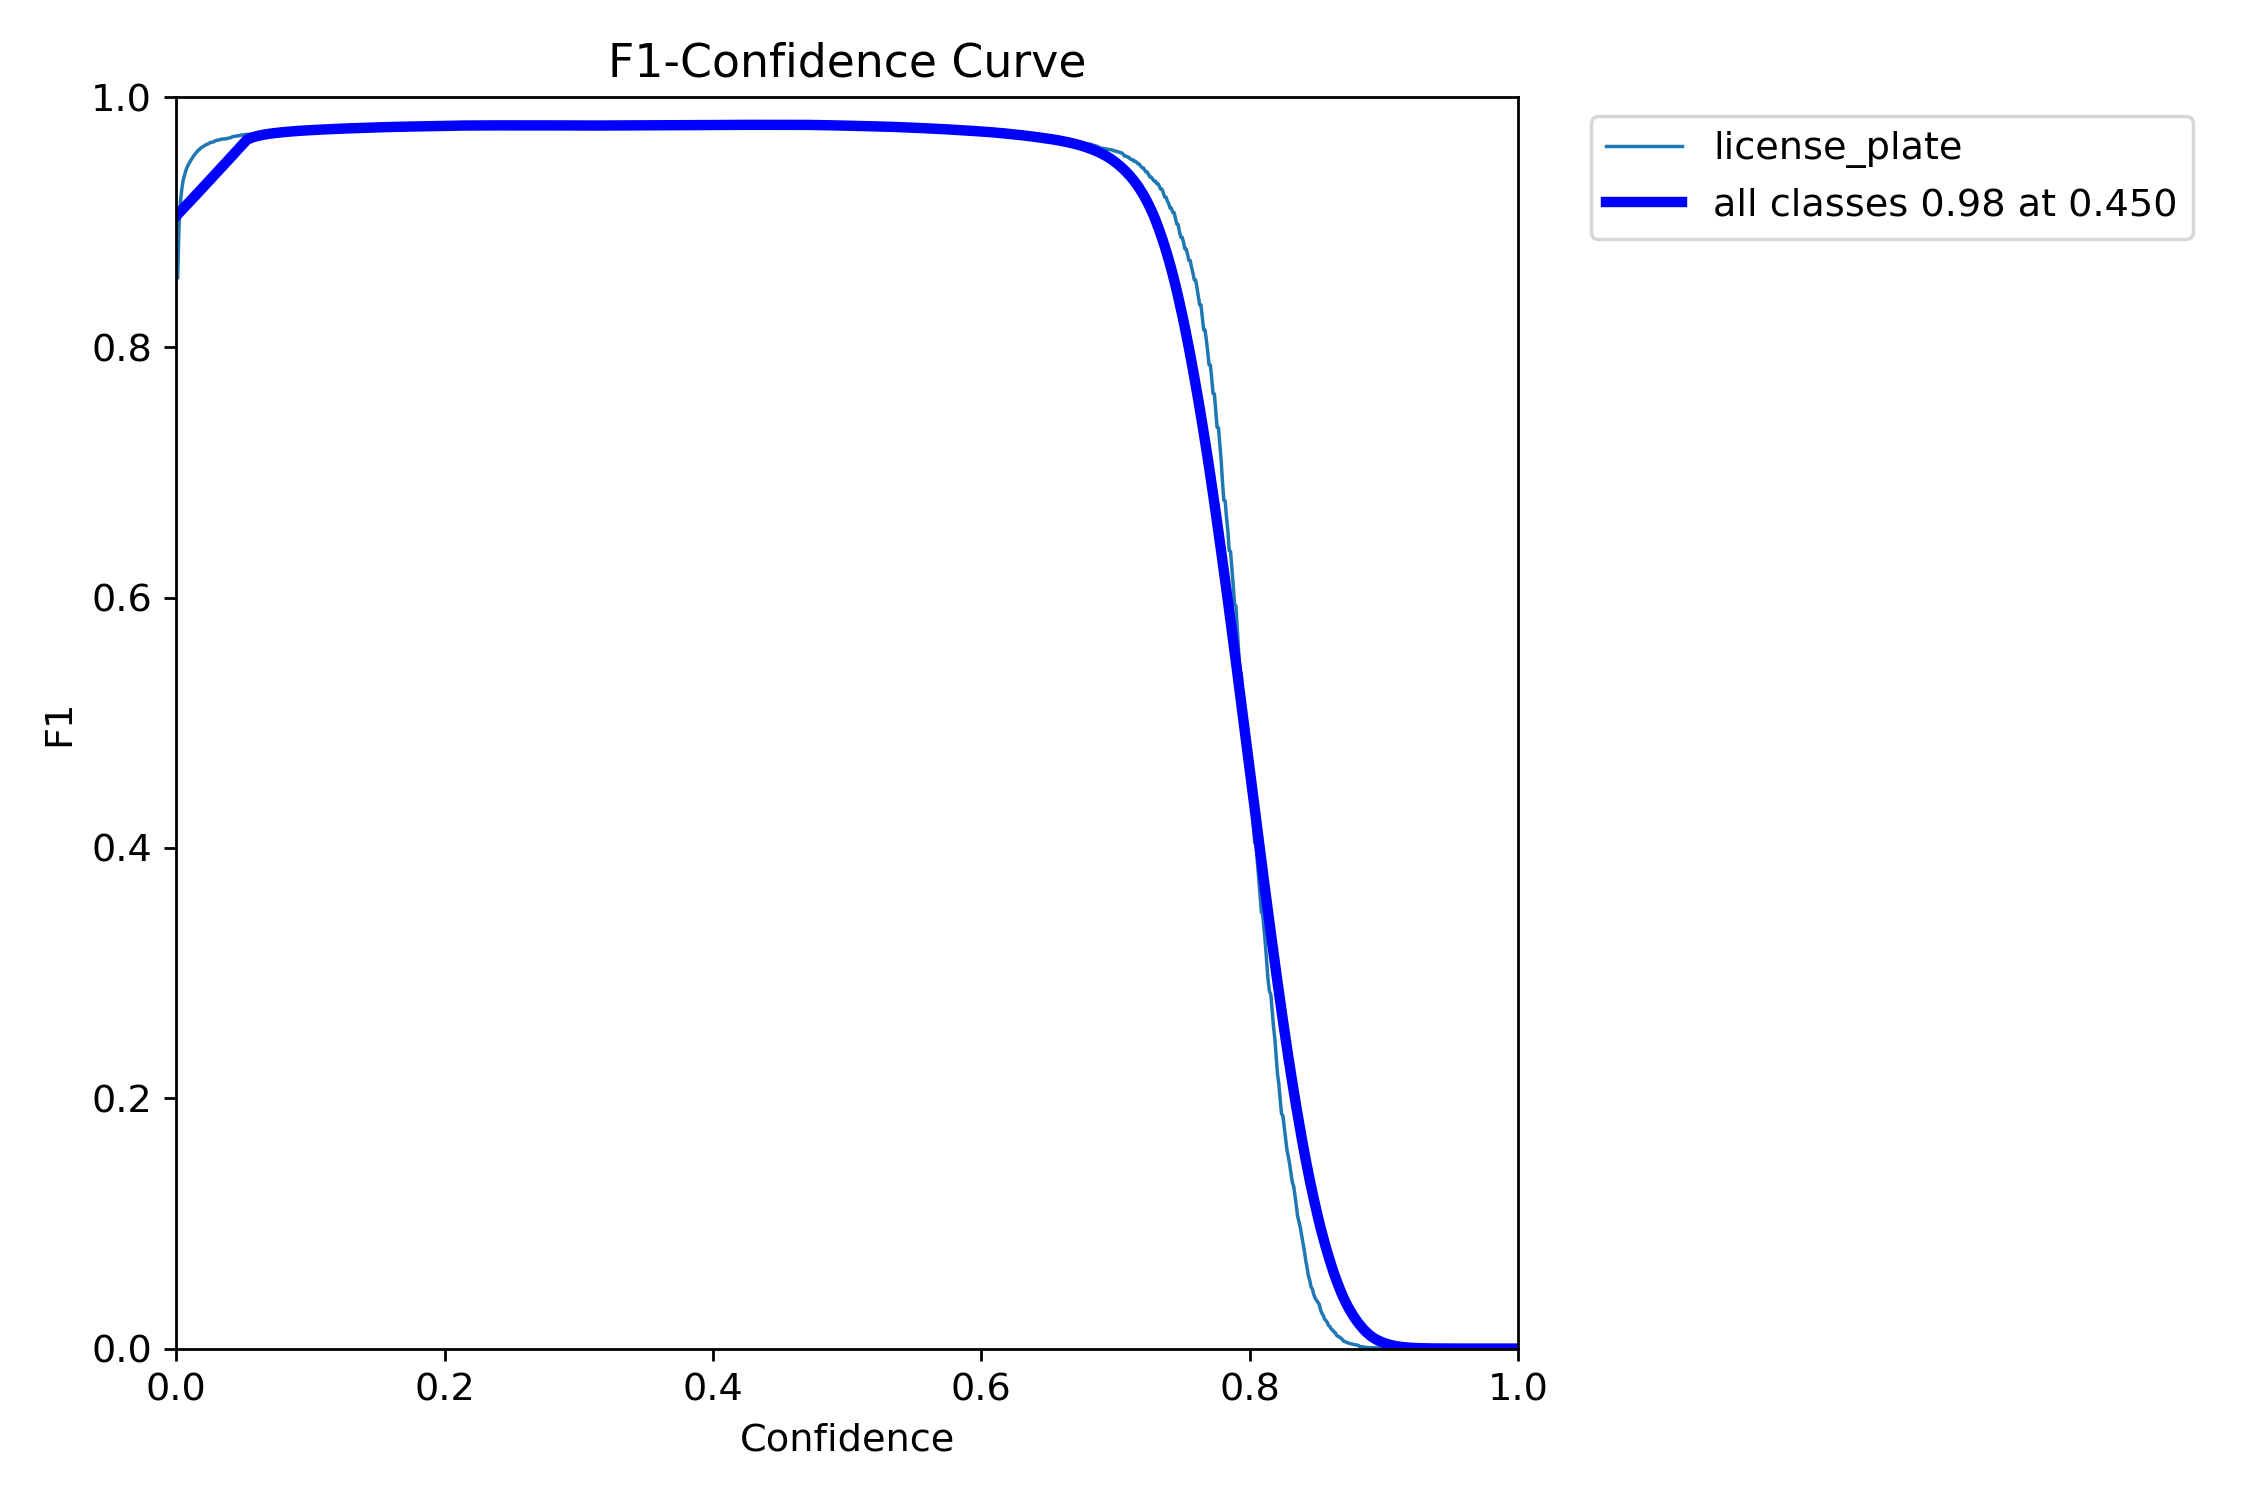

In [31]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/BoxF1_curve.png"))

<div style="background-color:#e4c1f9; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Confusion Matrix (confusion_matrix.png)</h1>
</div>

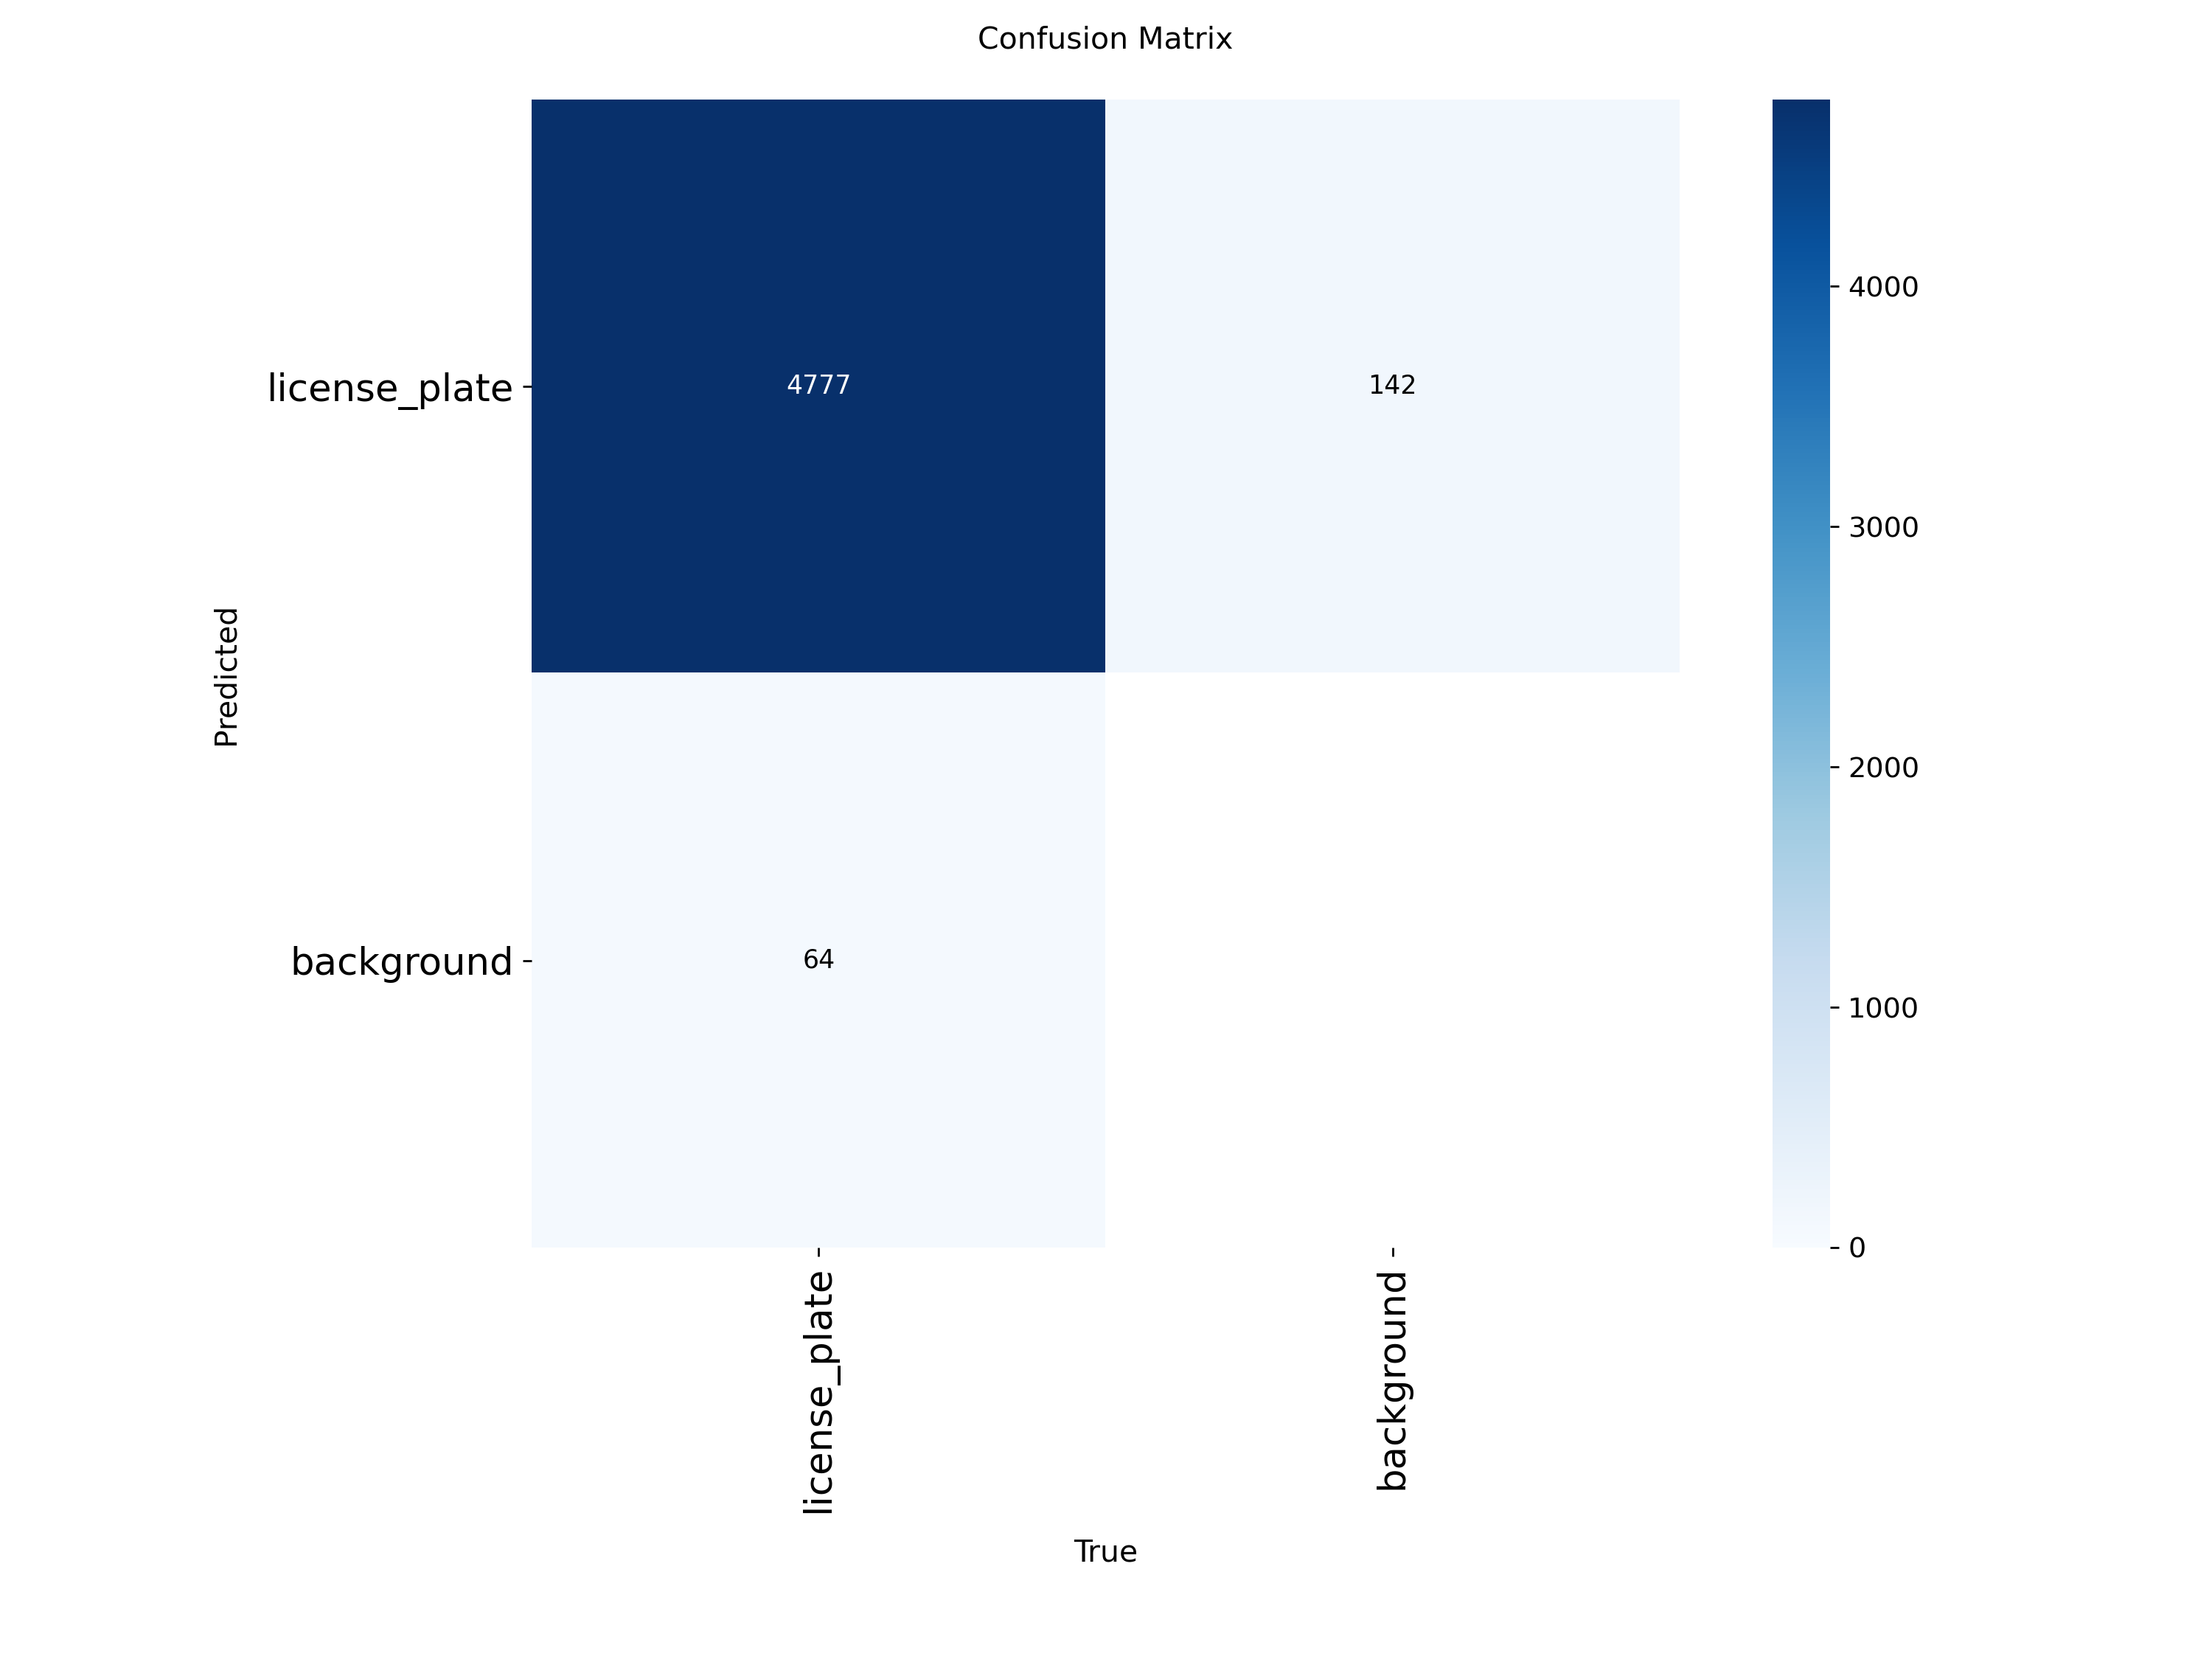

In [32]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/confusion_matrix.png"))

<div style="background-color:#d0f4de; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Confusion Matrix (Normalized) (confusion_matrix_normalized.png)</h1>
</div>

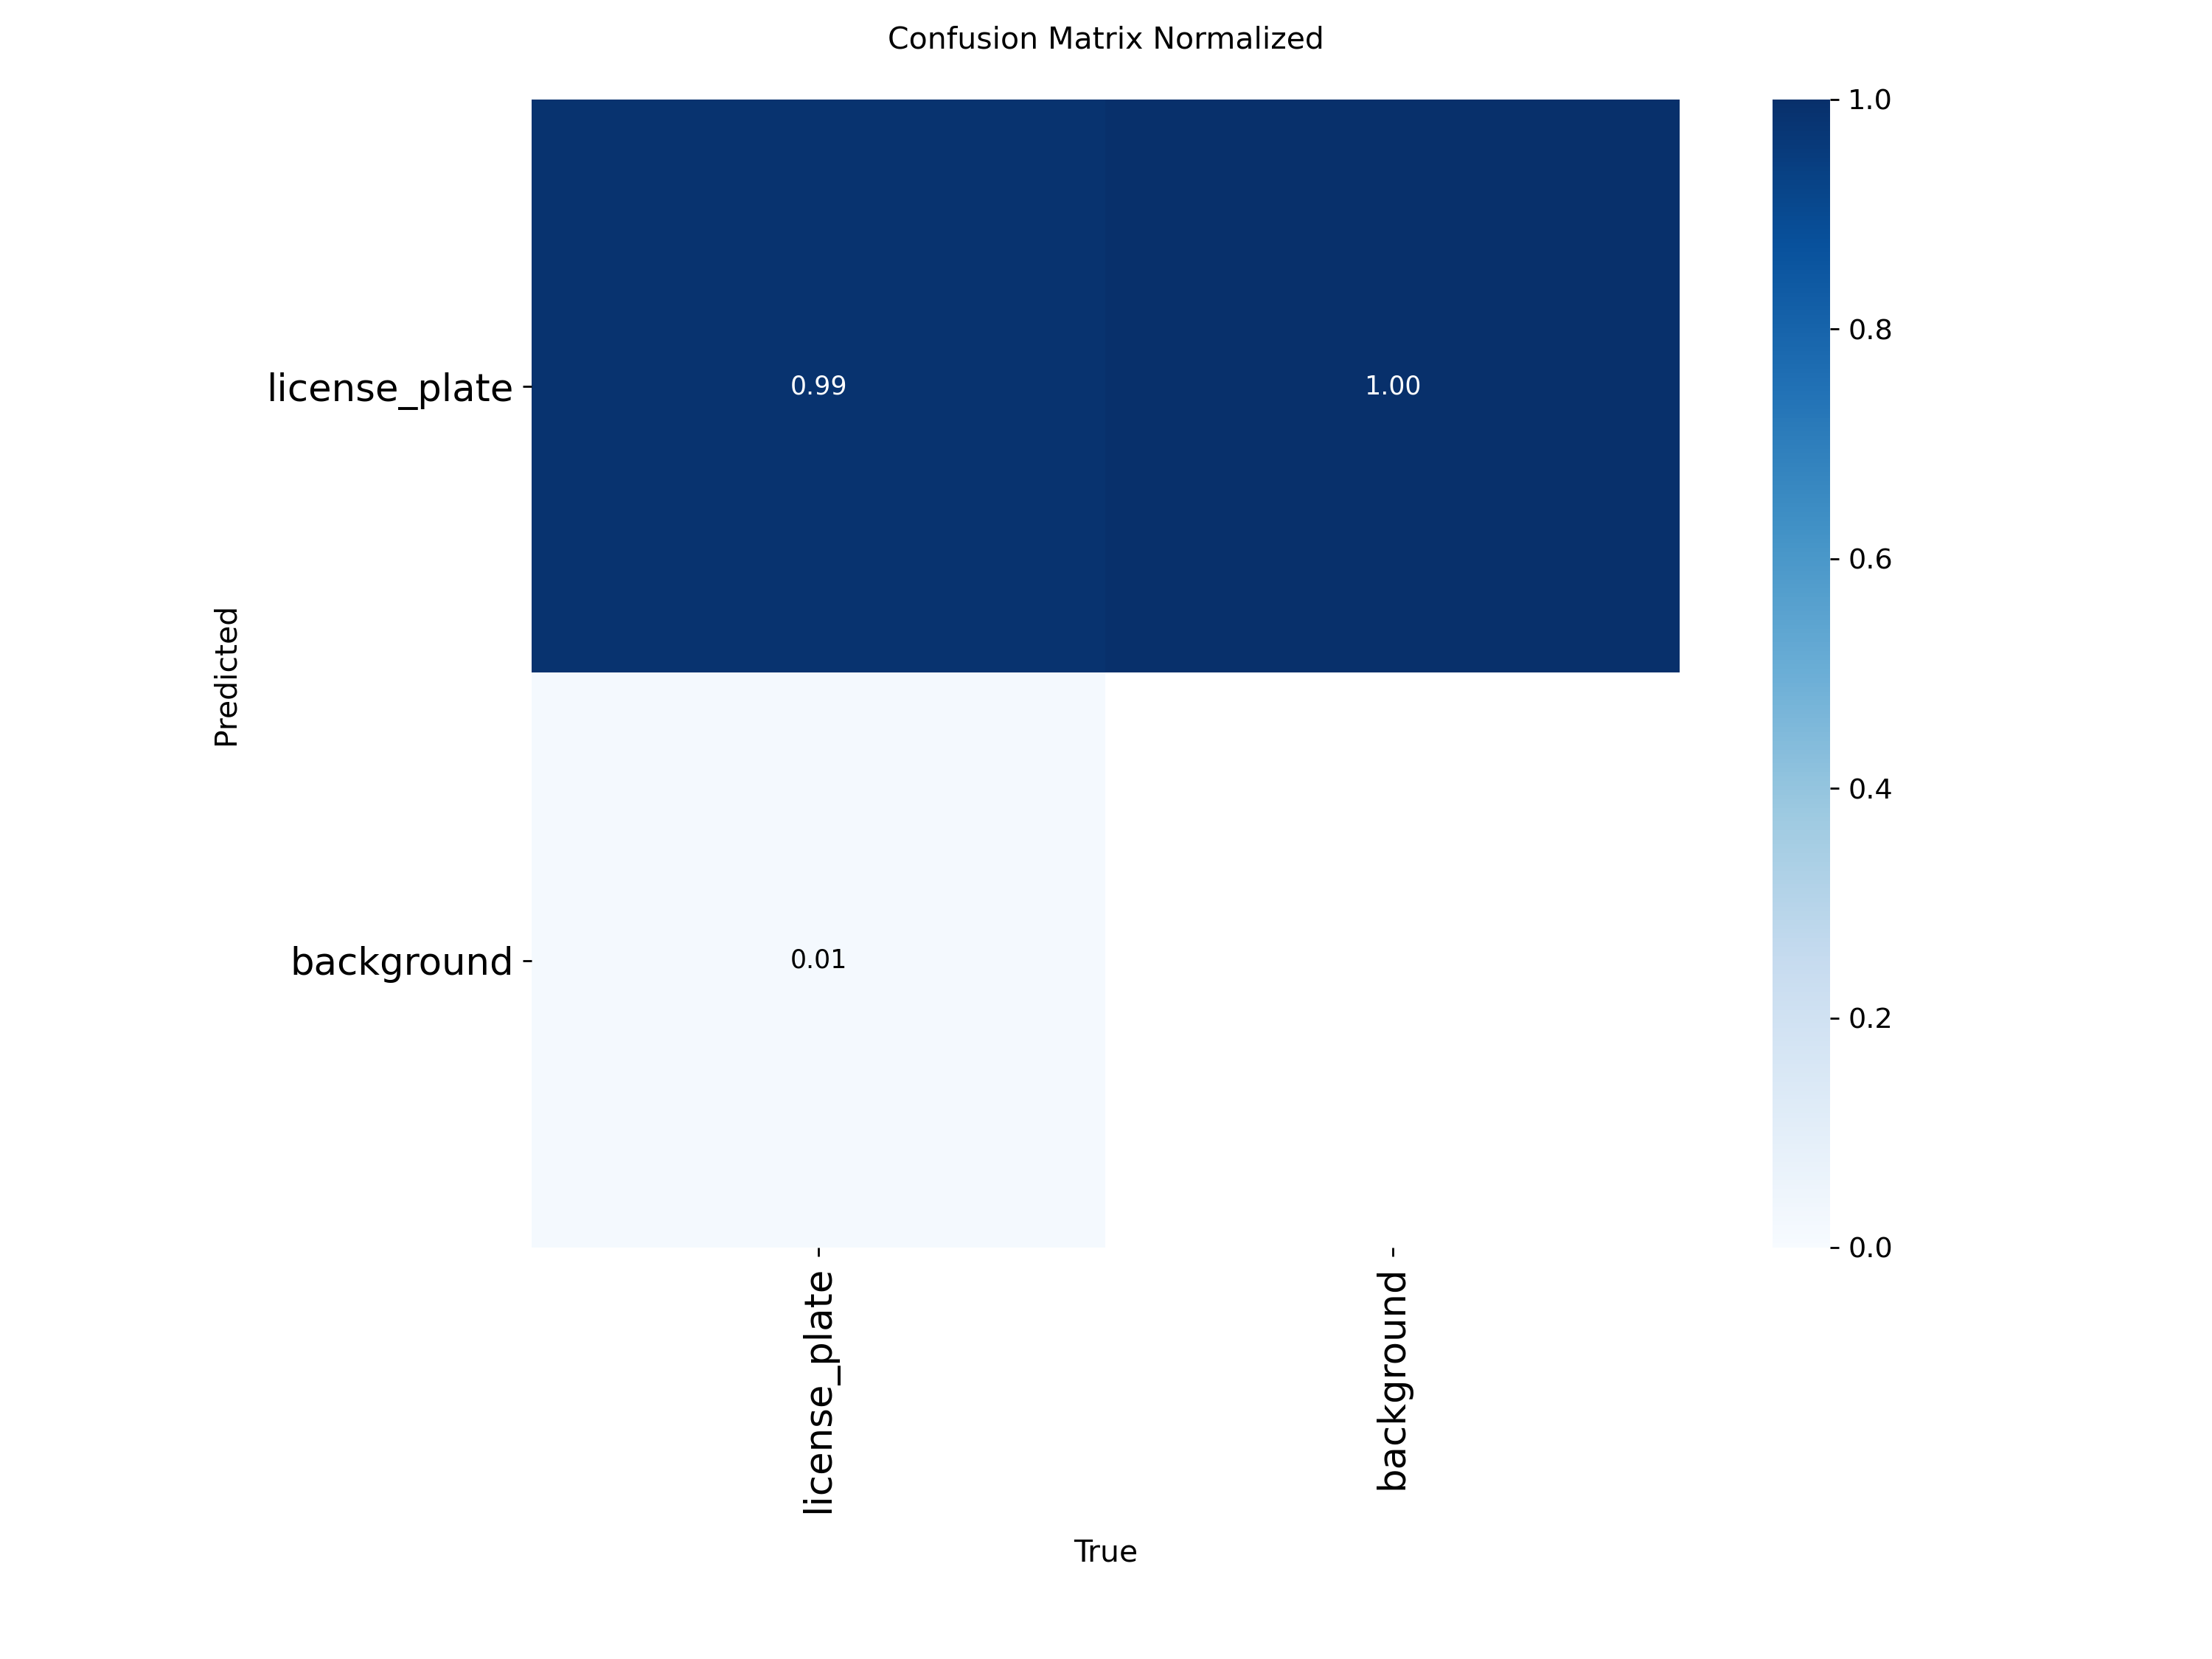

In [33]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/confusion_matrix_normalized.png"))

<div style="background-color:#caffbf; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#333;"> Labels Distribution (labels.jpg)</h1>
</div>

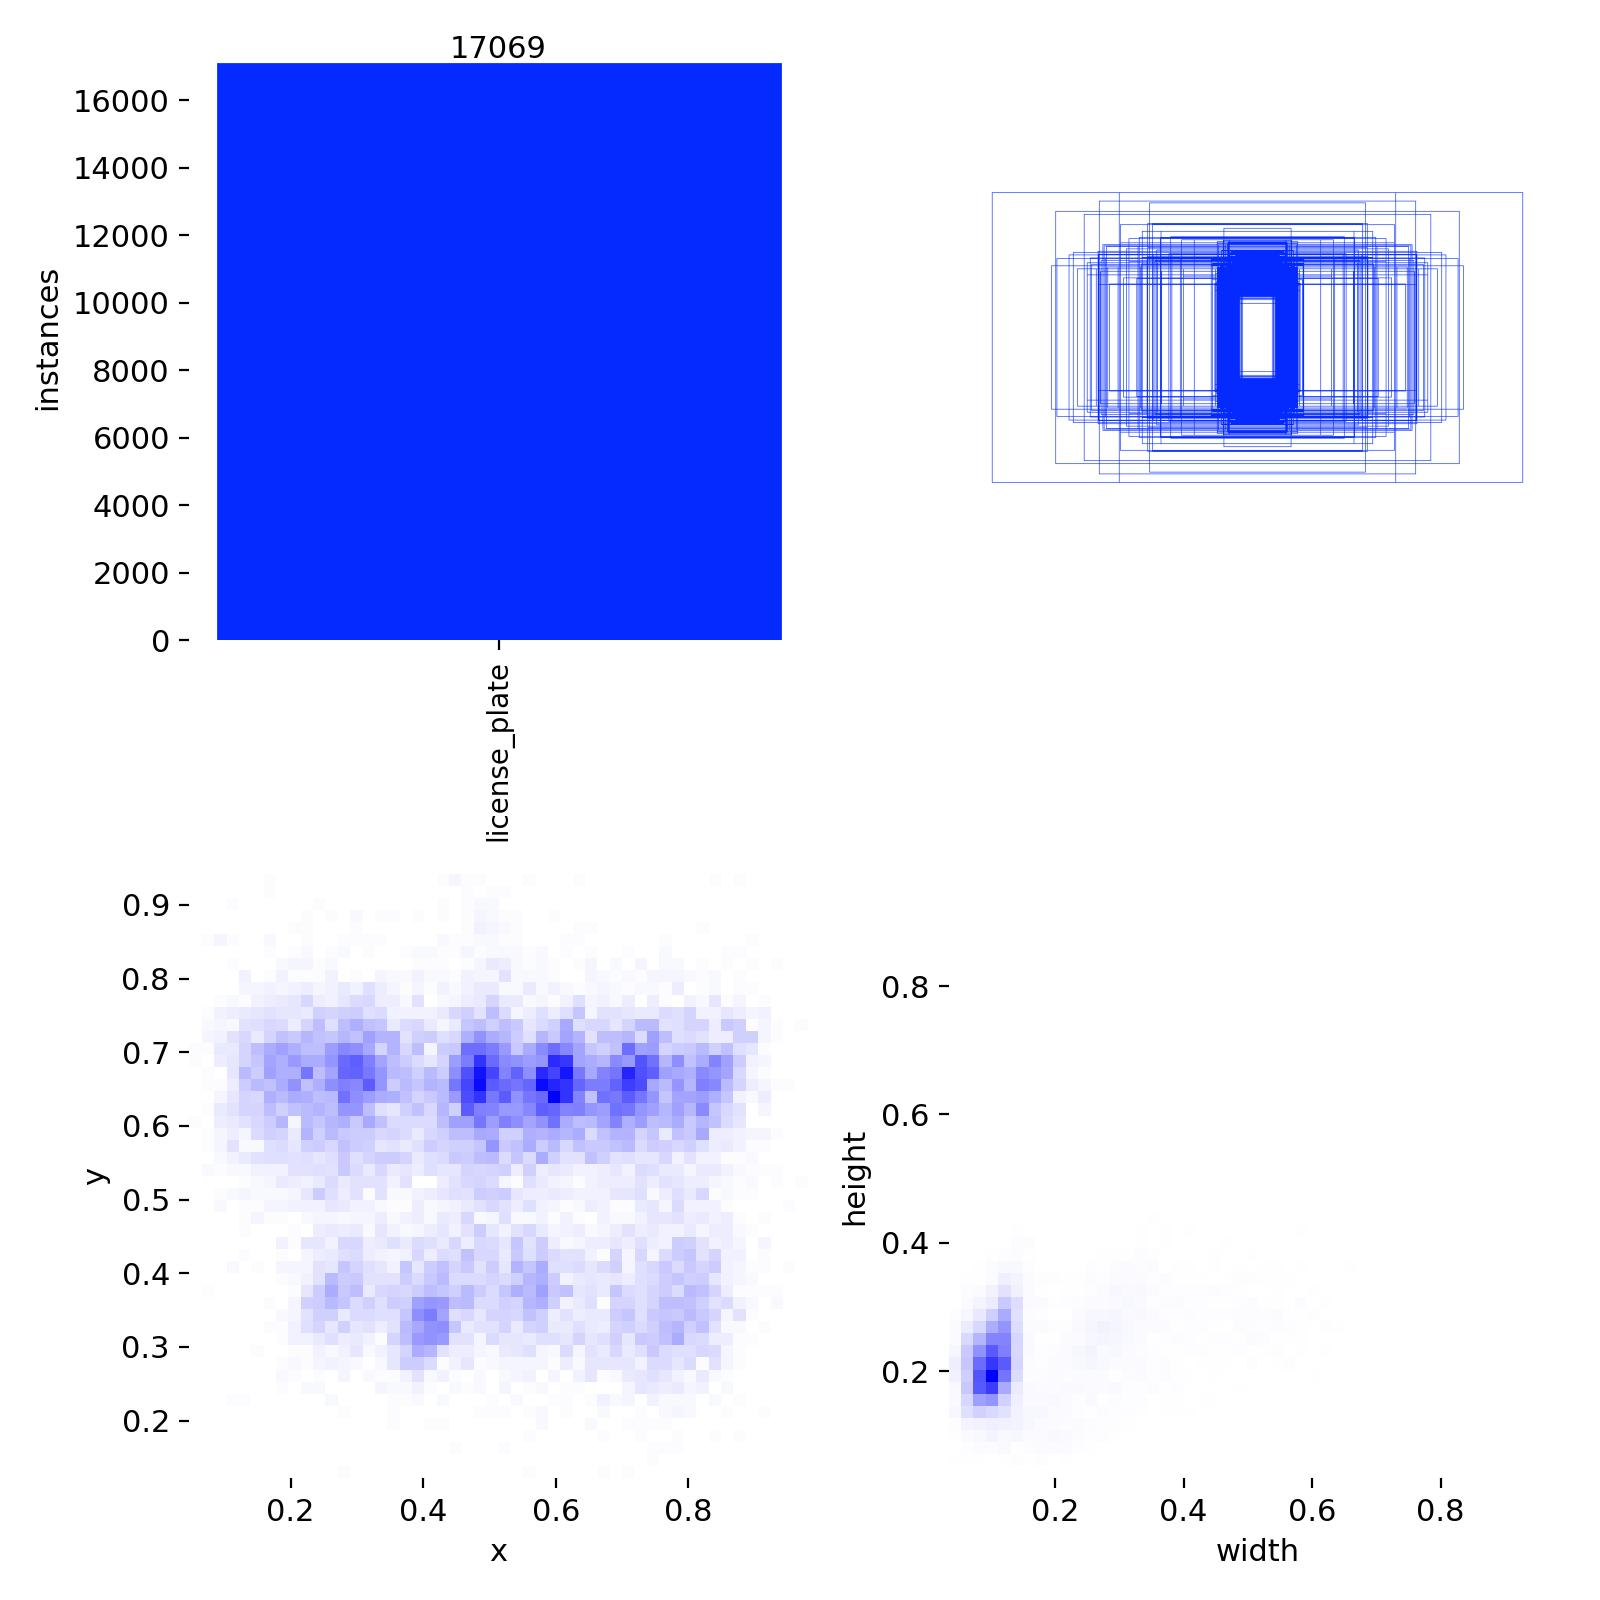

In [35]:
from IPython.display import Image, display

display(Image(filename="/kaggle/working/yolov9/runs/detect/train/labels.jpg"))

In [36]:
!apt install tesseract-ocr -y
!apt install tesseract-ocr-ben -y
!pip install pytesseract opencv-python-headless -q


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 141 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-ben
0 upgraded, 1 newly installed, 0 to remove and 141 not upgraded.
Need to get 516 kB of archives.
After this operation, 870 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ben all 1:4.00~git30-7274cfa-1.1 [516 kB]
Fetched 516 kB in 0s (4,421 kB/s)         

78Selecting previously unselected package tesseract-ocr-ben.
(Reading database ... 125128 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ben_1%3a4.00~git30-7274cfa-1.1_all.deb ...
7Progress: [  0%] [..................................................

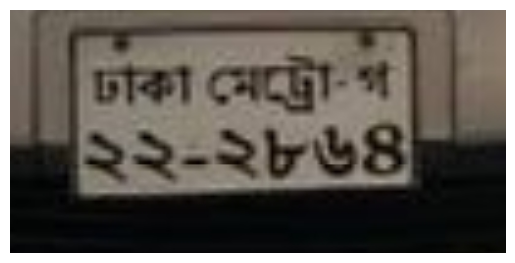

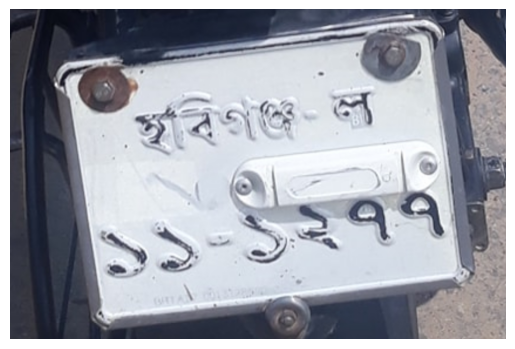

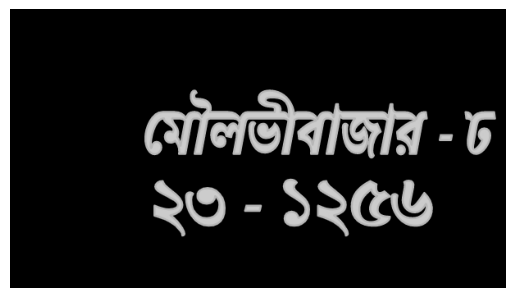

In [37]:
import cv2, pytesseract, matplotlib.pyplot as plt

images = [
    "/kaggle/working/LPDB_Merged_Full/Bangla_License_Plate_2100.jpg",
    "/kaggle/working/LPDB_Merged_Full/Bangla_License_Plate_1010.jpg",
    "/kaggle/working/LPDB_Merged_Full/Bangla_License_Plate_1251.jpg"
]

for idx, path in enumerate(images, 1):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    text = pytesseract.image_to_string(gray, lang='ben+eng')
   
    
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
  
    plt.show()


In [38]:
!ls /kaggle/working/yolov9


benchmarks.py  figure	   requirements.txt  train.py	      val.py
classify       hubconf.py  runs		     train_triple.py  val_triple.py
data	       models	   scripts	     ultralytics      yolo26n.pt
detect.py      panoptic    segment	     utils
export.py      README.md   train_dual.py     val_dual.py


<div style="background-color:#80ed99; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#222;"> YOLOv9 Model Export & Verification Completed</h1>
</div>

In [40]:
import os
import shutil

save_dir = '/kaggle/working/final_results'
os.makedirs(save_dir, exist_ok=True)

model_src = '/kaggle/working/yolov9/runs/detect/train/weights/best.pt'

if os.path.exists(model_src):
    shutil.copy(model_src, save_dir)
    print(f" YOLOv9 model copied to: {os.path.join(save_dir, os.path.basename(model_src))}")
else:
    print(" Model file not found:", model_src)

 YOLOv9 model copied to: /kaggle/working/final_results/best.pt


<div style="background-color:#b9fbc0; padding:10px; border-radius:8px; text-align:center;">
  <h1 style="margin:0; color:#222;"> Thank You!</h1>
</div>
